In [102]:
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from kan import KAN as PyKAN
from torch import nn

plt.rcParams.update({'font.size': 18})
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Torque target Stochastic Regression

In this notebook we're going to train a `PyKAN`, an `EfficientKAN`, and a `MLP` to learn a function that maps each set of input features to its own probability distribution.

We assume that the underlying process has many small, independent disturbances. Thus, Leveraging the Central limit theorem, we can say that the error between the model's prediction and **the actual observed value is likely to be normal**.

## Load dataset

In [3]:
original_df = pd.read_csv('../dataset/0-original/X.csv').drop(columns=['id', 'pa', 'ias'])
preprocessed_df = pd.read_csv('../dataset/2-regression/X.csv')
df_x = pd.concat([original_df, preprocessed_df], axis=1)
df_y = pd.read_csv('../dataset/2-regression/y.csv')['trq_target']

dataset_x = torch.tensor(df_x.values, dtype=torch.float32, device=device)
dataset_x = (dataset_x - dataset_x.mean(dim=0)) / dataset_x.std(dim=0)
dataset_y = torch.tensor(df_y.values, dtype=torch.float32, device=device).unsqueeze(1)
dataset_y = (dataset_y - dataset_y.mean(dim=0)) / dataset_y.std(dim=0)

In [4]:
class Py_KAN(nn.Module):
    def __init__(self, layers, grid_size=3):
        super(Py_KAN, self).__init__()
        self.layers = layers
        self.grid_size = grid_size
        self.model = PyKAN(width=self.layers, grid=self.grid_size, k=3, device=device)

    def forward(self, x):
        x = self.model(x)
        mu = x[:, 0]
        var = x[:, 1]
        return mu, var

In [5]:
pyKAN = Py_KAN(layers=[[len(df_x.columns), 0], [1, 0], [2, 0]], grid_size=2)

checkpoint directory created: ./model
saving model version 0.0


In [ ]:
pyKAN.model = PyKAN.loadckpt('models/torque_target_stochastic_small_12-23-01_8.pt')

## Plotting an inference

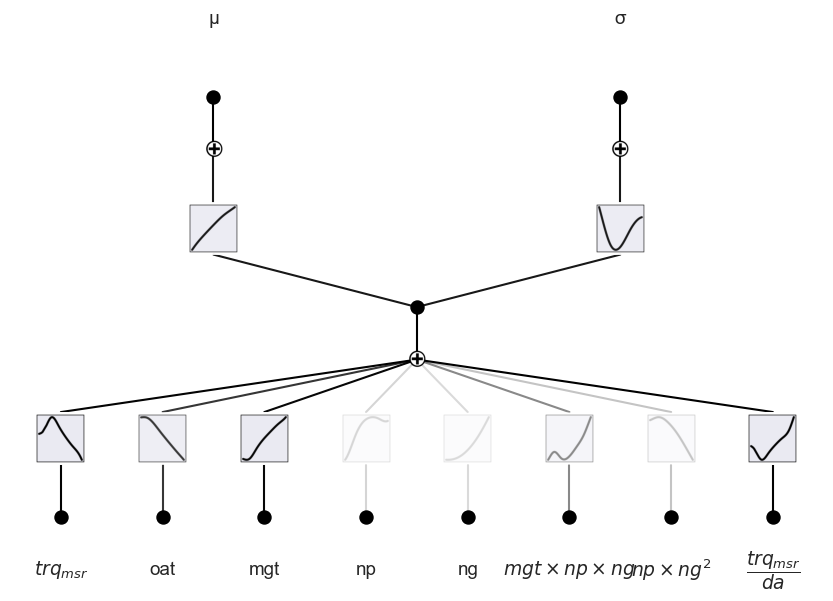

In [7]:
in_vars = ['$trq_{msr}$', 'oat', 'mgt', 'np', 'ng', '$mgt\\times np\\times ng$', '$np\\times ng^2$',
           '$\\dfrac{trq_{msr}}{da}$']
pyKAN.model.plot(scale=0.75, in_vars=in_vars, out_vars=['μ', 'σ'],
                 varscale=0.45, figsize_base=(14, 10))

In [103]:
def predict(model, batch_size=8192) -> pd.DataFrame:
    model.eval()
    predictions = []

    with torch.no_grad():
        for i in range(math.ceil(dataset_x.size(0) / batch_size)):
            x = dataset_x[i * batch_size:min(dataset_x.size(0), (i + 1) * batch_size)]
            mu, _ = model(x)
            mu = mu * df_y.std() + df_y.mean() # <-- De-normalization
            predictions.extend(mu.detach().cpu().numpy().tolist())
    return pd.DataFrame({'trq_target': predictions})

In [104]:
prediction = predict(pyKAN)

Text(0.5, 1.0, '$trq_{target}$ prediction')

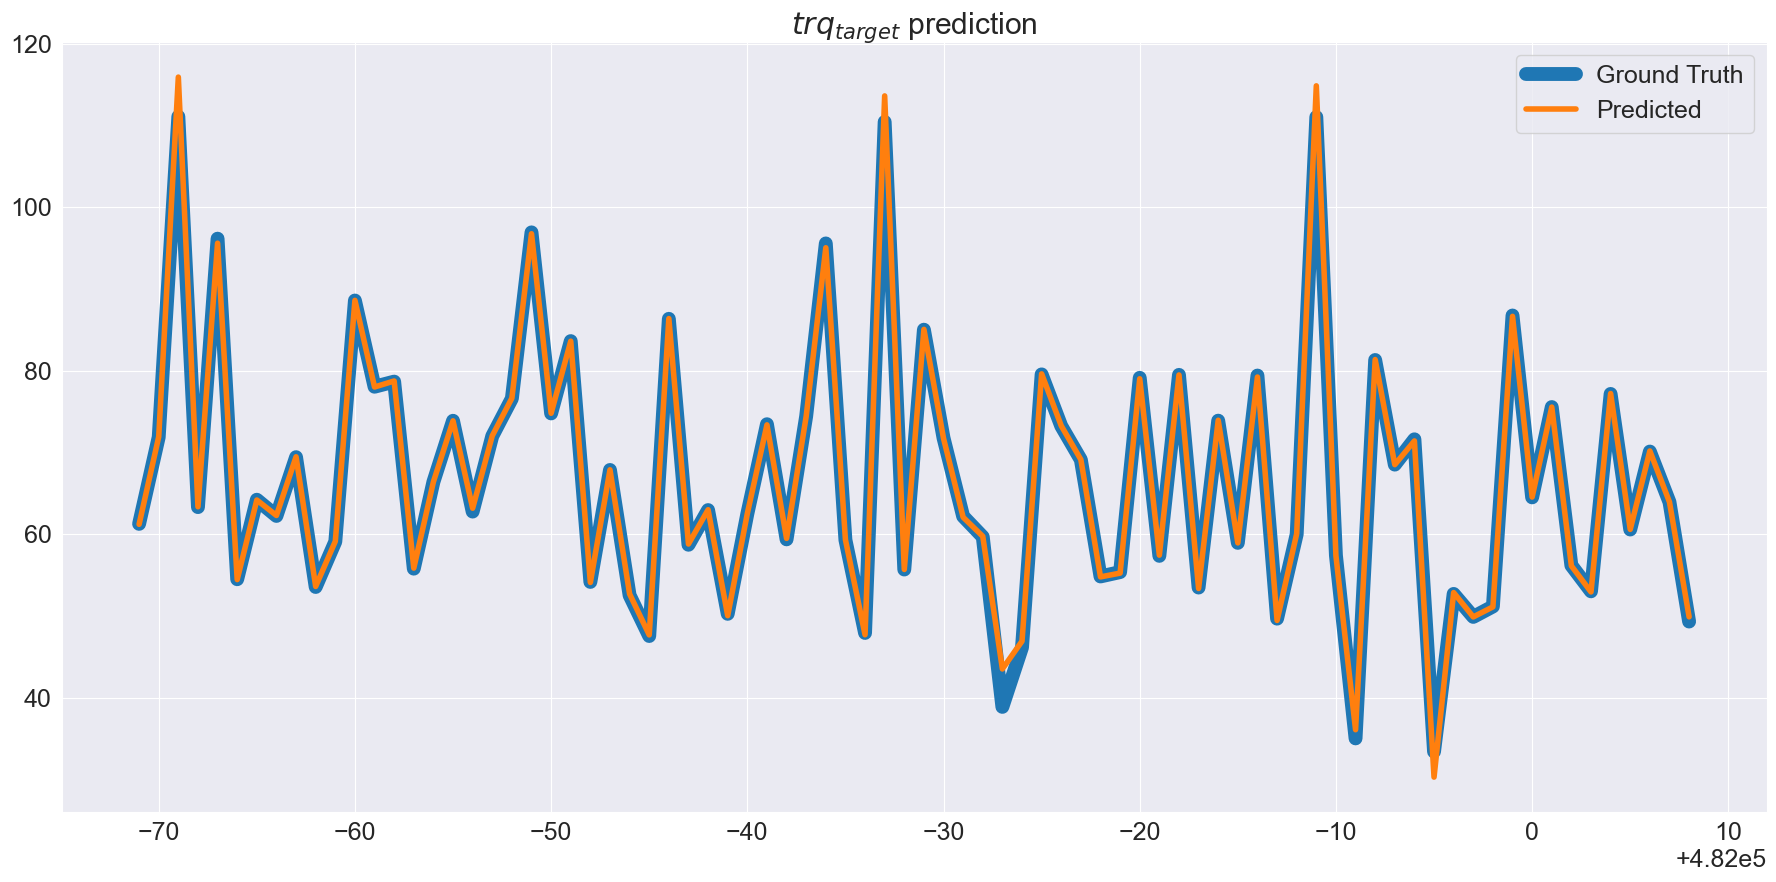

In [106]:
LENGTH = 80
i = random.randint(0, len(df_y) - LENGTH)
ax = df_y[i:i + LENGTH].plot(figsize=(22, 10), linewidth=10, label='Ground Truth')
prediction['trq_target'][i:i + LENGTH].plot(ax=ax, linestyle='-', linewidth=4, label='Predicted')
ax.legend()
ax.set_title('$trq_{target}$ prediction')

In [107]:
len(prediction), len(df_x)

(742625, 742625)

In [110]:
prediction['trq_margin'] = np.where(
    prediction['trq_target'] != 0,
    (df_x['trq_measured'] / prediction['trq_target'] - 1) * 100,
    0
)
prediction = prediction.replace('unset', 0).astype(float)
prediction.to_csv('prediction.csv', index=False)